In [1]:
import pandas as pd
import warnings
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
warnings.simplefilter("ignore")
pd.set_option('display.max_columns',200,'display.max_rows',1000,'display.max_colwidth',None,'mode.chained_assignment',None,'display.float_format','{:.2f}'.format)
np.set_printoptions(legacy = "1.25") # legacy = 1.25

In [3]:
df = pd.read_csv("5. CSV Challenge.csv", encoding = 'latin-1')
df.shape

(930, 15)

In [4]:
df.head(3)

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024


**Se muestran dispositivos móviles desde el año 2014 de distintas marcas con la información de salida**

In [5]:
df['Launched Year'].value_counts()

Launched Year
2024    292
2023    184
2022    149
2021    109
2020    101
2019     46
2018     21
2025     12
2017      9
2016      5
2014      2
Name: count, dtype: int64

**Evaluamos si tiene valores nulos**

In [6]:
df.isna().sum()

Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64

No existen

**Ahora evaluamos si existen duplicados**

In [7]:
df.loc[df.duplicated()]

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
347,Oppo,A3 128GB,186g,4GB,5MP,50MP,Snapdragon 6s 4G Gen 1,5000mAh,6.7 inches,"PKR 59,999","INR 34,999","CNY 2,999",USD 399,"AED 1,499",2024
437,Oppo,K11x 128GB,195g,8GB,16MP,108MP + 2MP,Qualcomm Snapdragon 695,"5,000mAh",6.72 inches,"PKR 59,999","INR 18,000","CNY 1,499",USD 199,"AED 1,000",2023
438,Oppo,K11x 256GB,195g,12GB,16MP,108MP + 2MP,Qualcomm Snapdragon 695,"5,000mAh",6.72 inches,"PKR 64,999","INR 20,000","CNY 1,699",USD 229,"AED 1,200",2023
441,Oppo,K10x 128GB,195g,6GB,16MP,64MP + 2MP + 2MP,Qualcomm Snapdragon 695,"5,000mAh",6.59 inches,"PKR 54,999","INR 16,990","CNY 1,499",USD 199,"AED 1,000",2022
442,Oppo,K10x 256GB,195g,8GB,16MP,64MP + 2MP + 2MP,Qualcomm Snapdragon 695,"5,000mAh",6.59 inches,"PKR 59,999","INR 18,990","CNY 1,699",USD 229,"AED 1,200",2022
443,Oppo,K10 5G 128GB,205g,8GB,16MP,64MP + 8MP + 2MP,MediaTek Dimensity 8000-Max,"5,000mAh",6.59 inches,"PKR 64,999","INR 19,999","CNY 1,799",USD 249,"AED 1,300",2022
445,Oppo,K9x 128GB,194g,6GB,16MP,64MP + 2MP + 2MP,MediaTek Dimensity 810,"5,000mAh",6.5 inches,"PKR 49,999","INR 15,999","CNY 1,499",USD 199,"AED 1,000",2021
446,Oppo,K9x 256GB,194g,8GB,16MP,64MP + 2MP + 2MP,MediaTek Dimensity 810,"5,000mAh",6.5 inches,"PKR 54,999","INR 17,999","CNY 1,699",USD 229,"AED 1,200",2021
447,Oppo,K9 Pro 5G 128GB,180g,8GB,16MP,64MP + 8MP + 2MP,MediaTek Dimensity 1200,"4,500mAh",6.43 inches,"PKR 69,999","INR 24,999","CNY 2,199",USD 299,"AED 1,500",2021
448,Oppo,K9 Pro 5G 256GB,180g,12GB,16MP,64MP + 8MP + 2MP,MediaTek Dimensity 1200,"4,500mAh",6.43 inches,"PKR 74,999","INR 27,999","CNY 2,499",USD 329,"AED 1,700",2021


Eliminamos duplicados

In [8]:
df = df.drop_duplicates()
df.shape

(915, 15)

Detectamos que la mayoria de las variables incluyen la nomenclatura, es decir, **Mobile Weight (peso)** incluye la _"g"_ de gramos, el **precio en dolares** incluye el _USD_, etc.

Por lo que, es necesario una limpieza para únicamente dejar el valor númerico y así convertir los datos a enteros.

In [9]:
# Verificamos como se almacena el precio. Vemos que cuando el número es mayor a 1K, usa el separador de comas. Por tanto, los decimales los usa con ".". 
# Entonces, checamos que así sea
for ele in df.columns[df.columns.str.contains('Price',na = False, regex = True, case = False)]:
    if df.loc[df[ele].str.contains('\.\d{2}$', na = False, regex = True, case = False)].shape[0] > 0: # detecta 1567.90
        print(ele)
    if df.loc[df[ele].str.contains(',\d{2}$', na = False, regex = True, case = False)].shape[0] > 0: # detecta 1567,90
        print(ele)

Launched Price (USA)
Launched Price (USA)


Vemos que solamente hay decimales correctos e incorrectos en el precio proveniente de USA. Entonces

In [10]:
# Eliminamos la coma de todo el df y corregimos los casos mencionados anteriormente
df.loc[df['Launched Price (USA)'].str.contains(',\d{2}$', na = False, regex = True, case = False),'Launched Price (USA)'] = df['Launched Price (USA)'].replace({',':'.'}, regex = True)
df = df.replace({',':''}, regex = True)

In [11]:
# Seleccionamos las columnas a limpiar (no en todas es necesaria)
cols = ['Mobile Weight','Battery Capacity', 'Screen Size','Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)','Launched Price (Dubai)', 'RAM']
for ele in cols:
    df[ele] = df[ele].str.extract("(\d+)") if ele != 'Screen Size' else df[ele].str.extract("(\d+\.\d*)")
    df[ele] = pd.to_numeric(df[ele], downcast = 'integer', errors = 'coerce')

In [12]:
df.head(2)

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174,6,12MP,48MP,A17 Bionic,3600,6.10,224999.00,79999,5799,799,2799,2024
1,Apple,iPhone 16 256GB,174,6,12MP,48MP,A17 Bionic,3600,6.10,234999.00,84999,6099,849,2999,2024


In [13]:
df.info() # verificamos

<class 'pandas.core.frame.DataFrame'>
Index: 915 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               915 non-null    object 
 1   Model Name                 915 non-null    object 
 2   Mobile Weight              915 non-null    int16  
 3   RAM                        915 non-null    int8   
 4   Front Camera               915 non-null    object 
 5   Back Camera                915 non-null    object 
 6   Processor                  915 non-null    object 
 7   Battery Capacity           915 non-null    int16  
 8   Screen Size                892 non-null    float64
 9   Launched Price (Pakistan)  914 non-null    float64
 10  Launched Price (India)     915 non-null    int32  
 11  Launched Price (China)     915 non-null    int16  
 12  Launched Price (USA)       915 non-null    int16  
 13  Launched Price (Dubai)     915 non-null    int16  
 14 

<html>
    <body>
        <H1>ANALISIS</H1>
        <br>
        Ahora bien, dado que tenemos casi toda la información de cada dispositivo vamos a realizar el analisis desde la especificación <b>menos importante</b> a la más importante según mi criterio (argumentado, obviamente). <br>Como se tienen <b>19</b> marcas distintas, vamos a analizar únicamente las 7 con más dispositivos en el mercado. 
    Dado que entre ellas representan más del 95% del mercado total (<a href="https://www.merca20.com/cuales-son-las-marcas-de-celulares-mas-vendidas-en-mexico/">Vease aqui</a>). 
        <br> 
        <ol>
            <li><p style="color:#00fea9";>Mobile Weight</p></li>
            <li><p style="color:#00fea9";>Battery Capacity</p></li>
            <li><p style="color:#00fea9";>Screen Size</p></li>
            <li><p style="color:#00fea9";>RAM</p></li>
            <li><p style="color:#00fea9";>Processor</p></li>
            <li><p style="color:#00fea9";>Launched Price</p></li>
        </ol>
        <br>
        Cada especificación tendrá un breve y preciso analisis donde podremos conocer más acerca de cada una de estas en el mercado.
        Finalmente, como bonus vamos a responder las siguientes preguntas:
        <ul>
            <li><p style="color:#02dbce";>¿Cuáles son los 3 dispositivos más caros historicamente?</p></li>
            <li><p style="color:#02dbce";>¿Cuáles son los 3 marcas más caras historicamente?</p></li>
            <li><p style="color:#02dbce";>¿Cuáles son los 3 marcas más baratas historicamente?</p></li>
            <li><p style="color:#02dbce";>¿Cuál es el celular con la mejor relacion bateria - pantalla historicamente?</p></li>
            <li><p style="color:#02dbce";>¿Cuándo comenzó la moda de la doble cámara trasera?</p></li>
        </ul>
    </body>
</html>

## 1. MOBILE WEIGHT

El peso es la especif. menos importante. De hecho, casi nadie elige un telefono bajo la premisa de escoger "el más ligero". En las tablets, quizá, importe un poco más. Sin embargo, gracias al avance tecnologico es un hito el que marcas lanzen dispositivos cada vez más delgados y por ende más ligeros.

In [14]:
# Obtenemos las 7 marcas con mas dispositivos registrados
marcas = df.groupby(by = 'Company Name', as_index = False)['Model Name'].count().rename(columns = {'Model Name':'Total'}) \
        .sort_values(by = 'Total', ascending = False)
marcas = marcas.head(7)

df = df.loc[df['Company Name'].isin(marcas['Company Name'])]
df.shape

(608, 15)

In [15]:
# Extraemos los datos de los pesos
peso = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Mobile Weight'].mean().rename(columns = {'Mobile Weight':'Peso_prom'})
peso.head(2)

,Launched Year,Company Name,Peso_prom
0,2014,Vivo,149.50
1,2016,Samsung,295.50


Lo anterior se puede ver reflejado aquí, donde vemos el comportamiento del **peso promedio a lo largo de los años por marca**

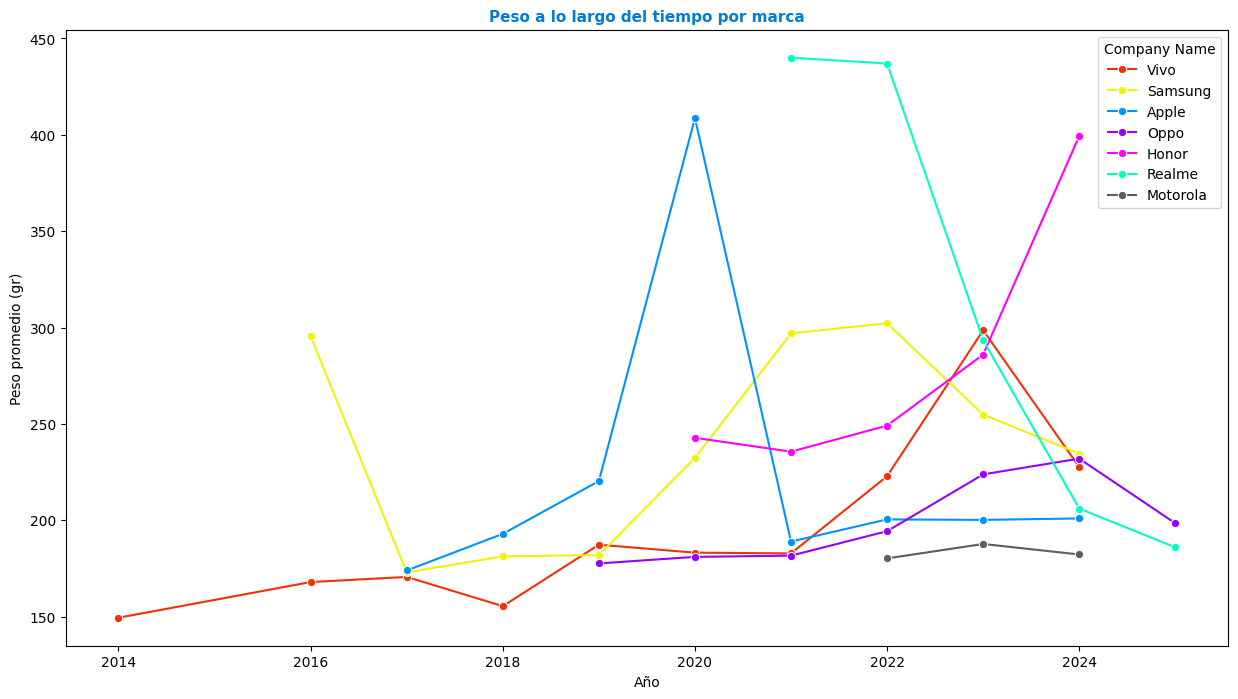

In [16]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
#sns.set_style("darkgrid")
sns.lineplot(data = peso, x = 'Launched Year', y = 'Peso_prom', hue = 'Company Name', palette = palette, marker = "o")
plt.title("Peso a lo largo del tiempo por marca", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("Peso promedio (gr)")
plt.show()

Aqui se aprecia como **<span style="color:#57db02">6 de las 7 marcas</span>** tienen una _tendencia a la baja_.

Otro dato interesante es ver la distribución de los pesos. Esto responde a la pregunta, ¿qué pesos predominan en el mercado?

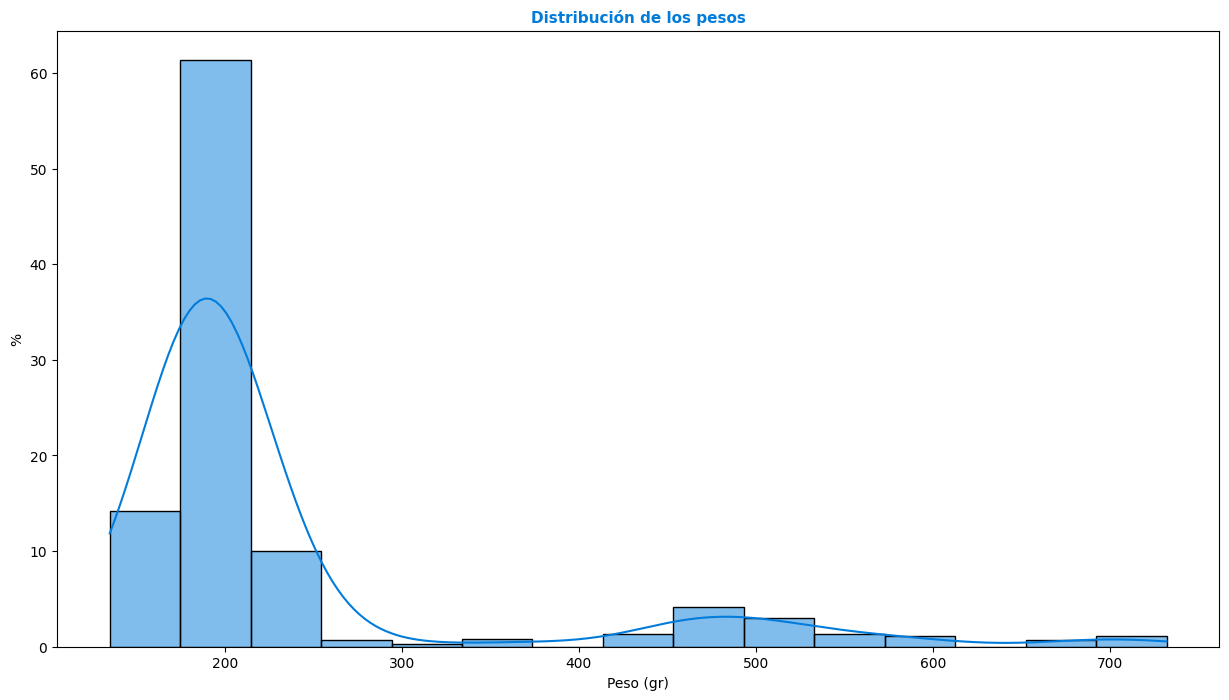

In [17]:
plt.figure(figsize = (15,8))
sns.histplot(df["Mobile Weight"],  kde = True, stat = "percent", color = "#027cdb", bins = 15)
plt.title("Distribución de los pesos", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.ylabel("%")
plt.xlabel("Peso (gr)")
plt.show()

Predominan los dispositivos con pesos **<span style="color:#57db02">inferiores a 250 gramos</span>**.

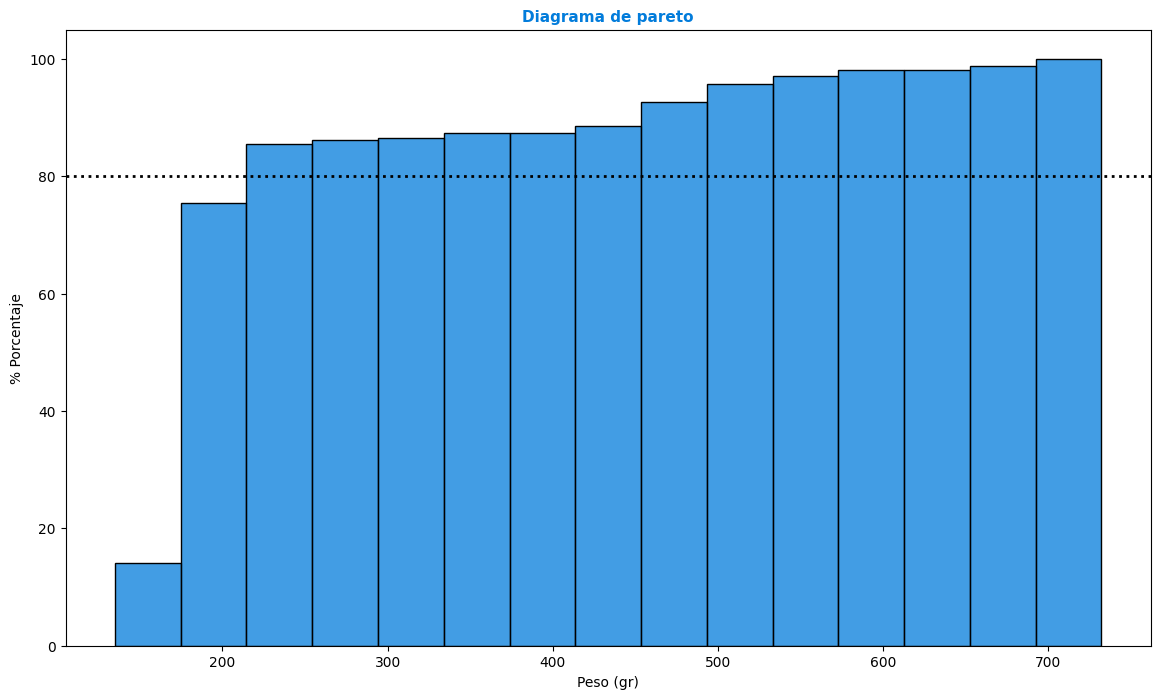

In [18]:
plt.figure(figsize = (14,8))
ax = sns.histplot(df["Mobile Weight"], stat = "percent", color = "#027cdb", cumulative = True, bins = 15)
ax.axhline(y = 80, linewidth = 2, color = 'black', ls = ':')
plt.title("Diagrama de pareto", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.ylabel("% Porcentaje")
plt.xlabel("Peso (gr)")
plt.show()

Además, con el sencillo "diagrama de pareto" es posible ver que el **<span style="color:#57db02">80% del peso de los dispositivos moviles se encuentran por debajo de los 300 gr</span>**

## 2. BATTERY CAPACITY

Debería ser importante, sin embargo, siendo honestos, ¿Sabes la capacidad de batería que tiene tu celular? Muy probablemente no. Justamente por eso no lo considero tan importante, dado que existen múltiples dispositivos con menor capacidad pero mejor batería que otro que tiene mayor. Esto se debe a la optimización de la capa de personalización que tiene más la pertinente del sistema operativo, apps, etc.

In [19]:
# Extraemos los datos de la bateria para ver el comportamiento a lo largo del tiempo
cap = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Battery Capacity'].mean().rename(columns = {'Battery Capacity':'Cap_media'})
cap.head(2)

,Launched Year,Company Name,Cap_media
0,2014,Vivo,2150.00
1,2016,Samsung,4150.00


Debido al avance tecnologico tanto en hardware, como en software, se espera que el amperaje de las baterias aumente, debido a que la tecnología lo requiere.

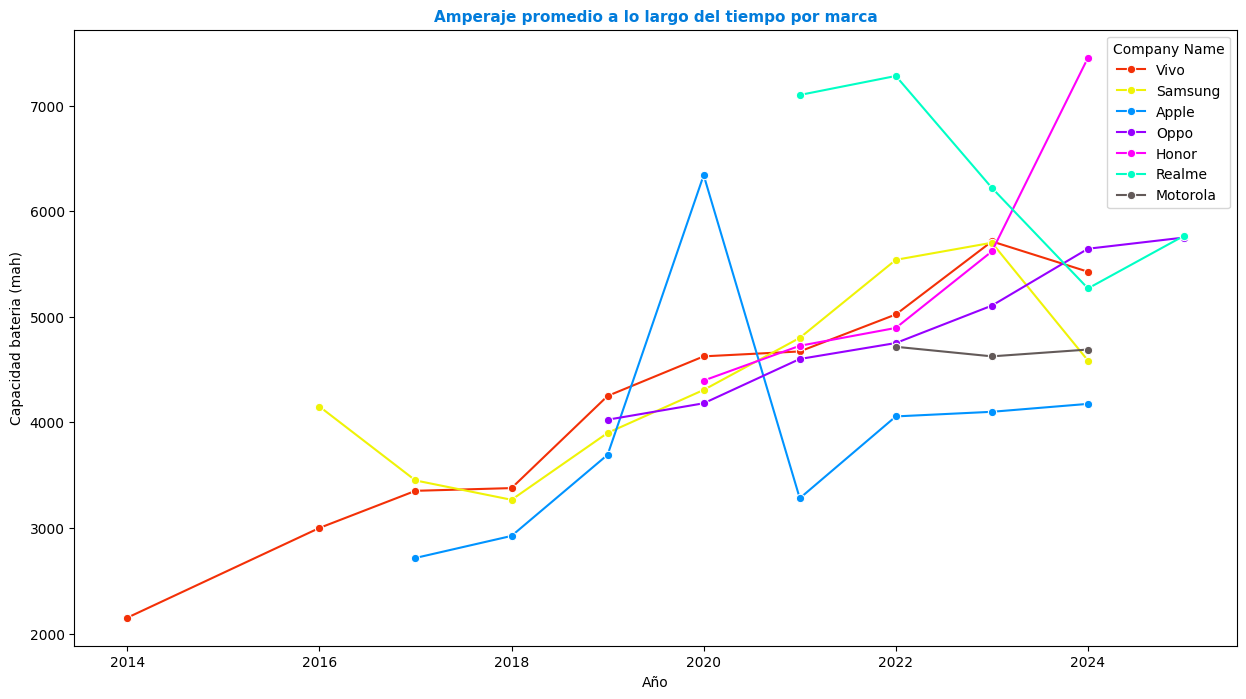

In [20]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
sns.lineplot(data = cap, x = 'Launched Year', y = 'Cap_media', hue = 'Company Name', palette = palette, marker = "o")
plt.title("Amperaje promedio a lo largo del tiempo por marca", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("Capacidad bateria (mah)")
plt.show()

Se observa un comportamiento curioso, poco más de la mitad de las marcas presentan una tendencia a la alza. Mientras que las demás marcas parecen mantenerse en el mismo rango, cuyas distribuciones se ven a continuacion:

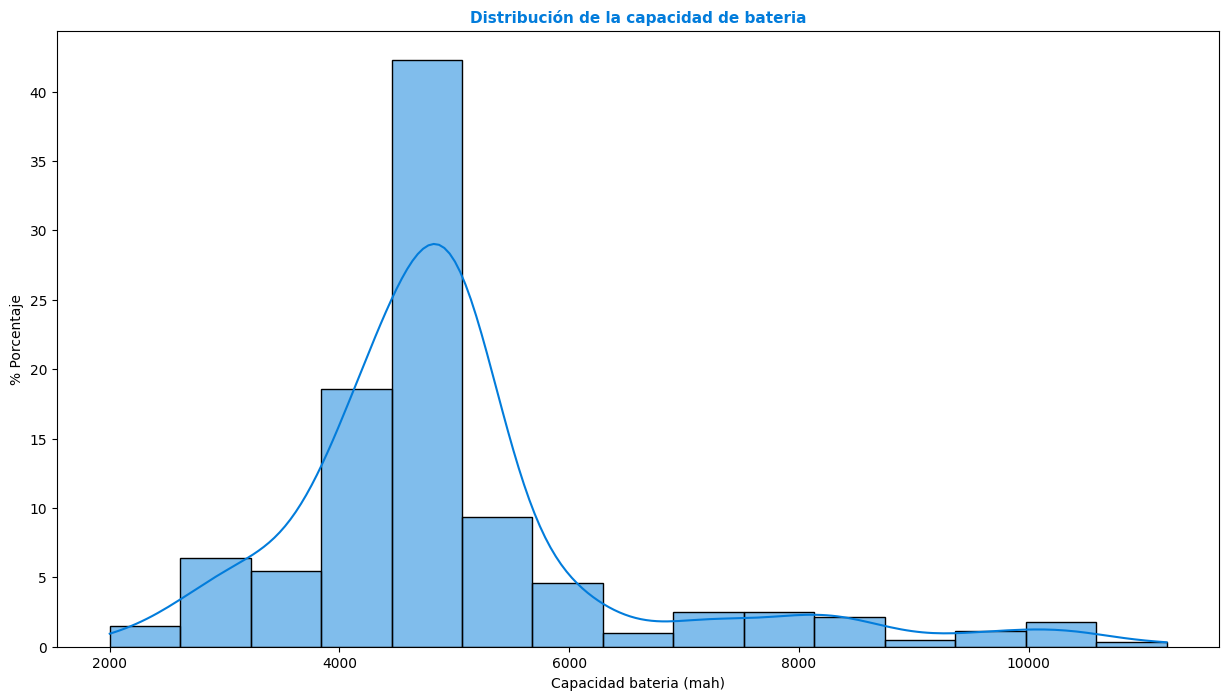

In [21]:
plt.figure(figsize = (15,8))
sns.histplot(df["Battery Capacity"],  kde = True, stat = "percent", color = "#027cdb", bins = 15)
plt.ylabel("% Porcentaje")
plt.xlabel("Capacidad bateria (mah)")
plt.title("Distribución de la capacidad de bateria", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

La mayoría de los dispositivos se encuentran con menos de **<span style="color:#57db02">6000 de amperaje</span>**.

Resulta interesante ver que existen varios valores atipicos. Esto se debe a que, a diferencia del peso, hay casos especiales donde es necesario que el amperaje aumente. Basta con revisar que **<span style="color:#57db02">todos los dispositivos con más de 8K de amperaje son tablets</span>** y que TODOS tienen **<span style="color:#57db02">pantallas mayores a 10 pulgadas</span>**.

In [22]:
df.loc[df['Battery Capacity'] > 8000]

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
82,Apple,iPad 10.2-inch 32GB,490,3,12MP,8MP,A13 Bionic,8612,10.20,49999.00,29900,2299,329,1199,2020
83,Apple,iPad 10.2-inch 128GB,490,3,12MP,8MP,A13 Bionic,8612,10.20,59999.00,39900,2699,429,1499,2020
89,Apple,iPad Pro 12.9-inch 128GB,682,6,7MP,12MP + 10MP,A12Z Bionic,9720,12.90,219999.00,94900,7999,999,3799,2020
90,Apple,iPad Pro 12.9-inch 256GB,682,6,7MP,12MP + 10MP,A12Z Bionic,9720,12.90,239999.00,109900,8699,1099,4199,2020
91,Apple,iPad Pro 12.9-inch 512GB,682,6,7MP,12MP + 10MP,A12Z Bionic,9720,12.90,259999.00,119900,9199,1299,4599,2020
92,Apple,iPad Pro 13-inch 128GB,708,6,7MP,12MP + 10MP,A12Z Bionic,10307,NaN,259999.00,119900,8699,1099,4499,2020
93,Apple,iPad Pro 13-inch 256GB,708,6,7MP,12MP + 10MP,A12Z Bionic,10307,NaN,279999.00,139900,9199,1199,4799,2020
94,Apple,iPad Pro 13-inch 512GB,708,6,7MP,12MP + 10MP,A12Z Bionic,10307,NaN,309999.00,159900,9799,1399,5299,2020
95,Apple,iPad Pro 13-inch 1TB,708,6,7MP,12MP + 10MP,A12Z Bionic,10307,NaN,359999.00,179900,10399,1599,5799,2020
96,Apple,iPad Pro 13-inch 2TB,708,6,7MP,12MP + 10MP,A12Z Bionic,10307,NaN,399999.00,199900,11199,1799,6099,2020


Inclusive, esas tablets explican, en parte, el porqué de la variación tan alta entre los distintos dispositivos de cada marca

In [23]:
cap = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Battery Capacity'].std().rename(columns = {'Battery Capacity':'Cap_std'})

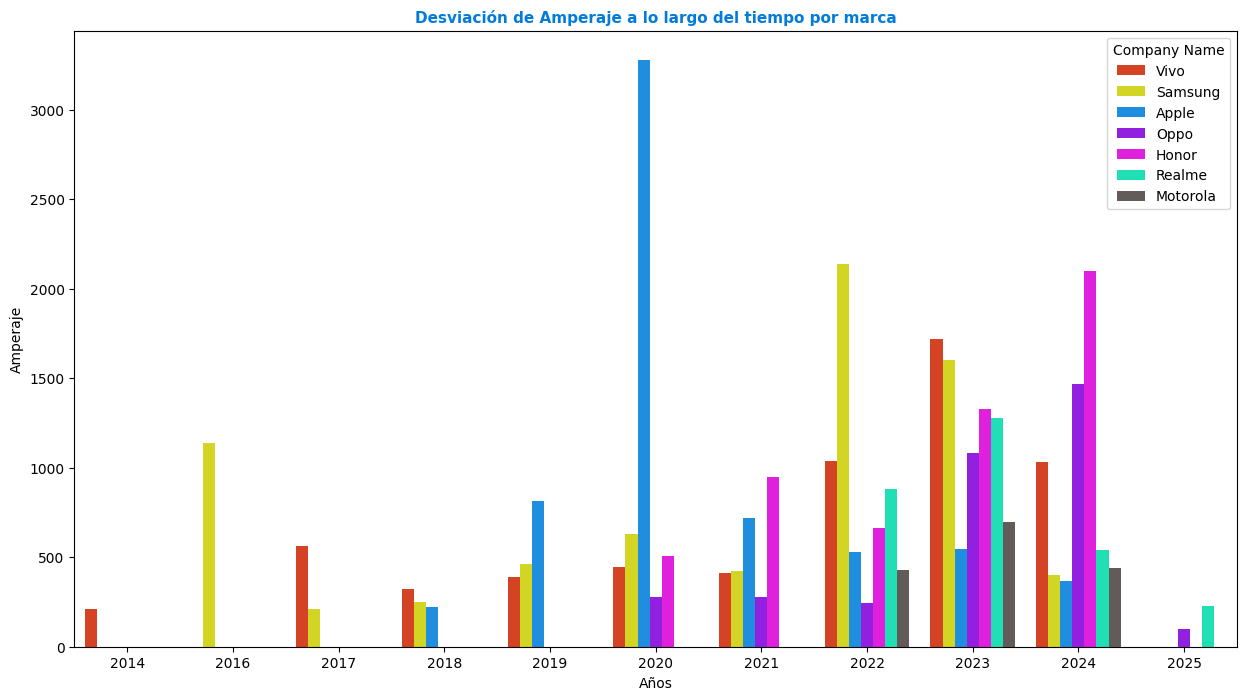

In [24]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
sns.barplot(data = cap,  x = 'Launched Year', y = 'Cap_std', hue = "Company Name", palette = palette)
plt.ylabel("Amperaje")
plt.xlabel("Años")
plt.title("Desviación de Amperaje a lo largo del tiempo por marca", fontsize = 11, fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

Apple es la marca que **<span style="color:#57db02">más cambio en el amperaje de las baterías realizo a lo largo de los años</span>**.

## 3. SCREEN SIZE

Okay, esta especificación ya comienza a importar. Hay muchas personas que no se sienten cómodas con dispositivos muy grandes, esto, inclusive esta presente en las tablets. Una tablet con una pantalla muy grande se vuelve tosca y díficl de transportar. Lo mismo con un dispositivo.

De hecho, uno de los factores por los cuáles elegí el celular que tengo es justamente el tamaño.

In [25]:
# Extraemos los datos del tamaño de la pantalla para ver el comportamiento a lo largo del tiempo
pat = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Screen Size'].median().rename(columns = {'Screen Size':'Pant_mediana'})
pat.head(2)

,Launched Year,Company Name,Pant_mediana
0,2014,Vivo,5.25
1,2016,Samsung,6.00


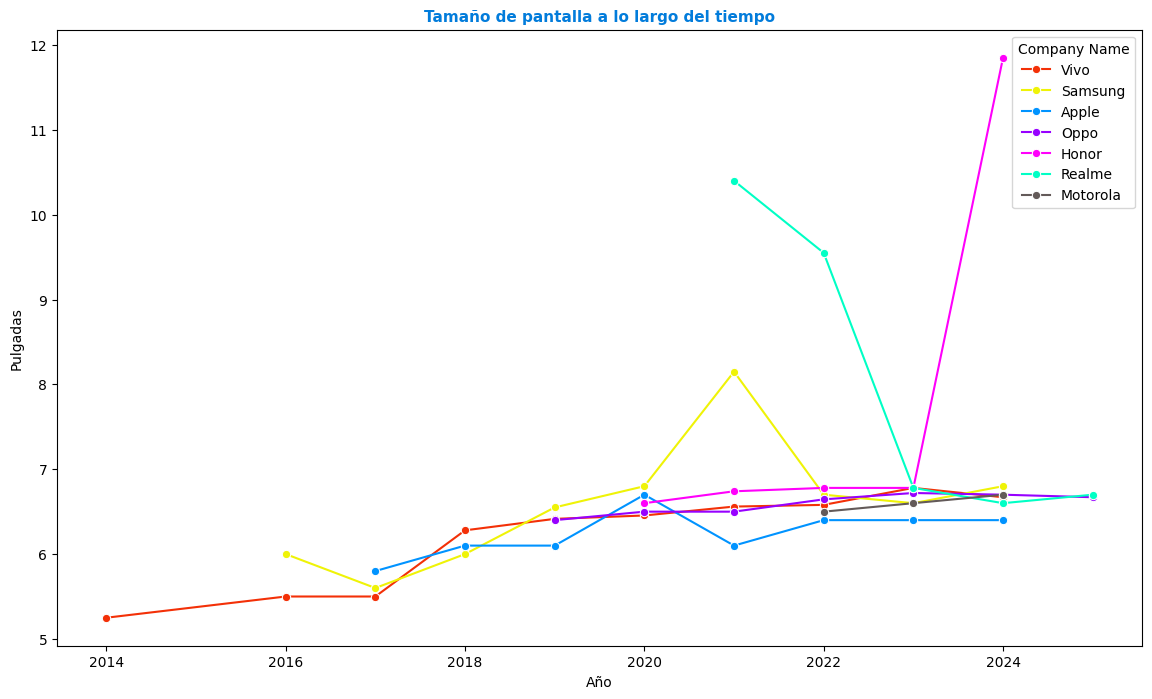

In [26]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (14,8))
sns.lineplot(data = pat, x = 'Launched Year', y = 'Pant_mediana', hue = 'Company Name', palette = palette, marker = "o")
plt.title("Tamaño de pantalla a lo largo del tiempo", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("Pulgadas")
plt.show()

En este caso, dado que hablamos de pantalla, no tiene sentido hablar de media, dado que las medidas de las pantallas están muy estandarizadas. Es imposible encontrar un dispositivo cuya pantalla mida 6.02 pulgadas. Ahora bien, en el gráfico **<span style="color:#57db02">se observa una tendencia constante entre 6 y 7 pulgadas</span>**, a lo largo de los años salvo la marca Honor. Esto queda más claro con el siguiente gráfico:

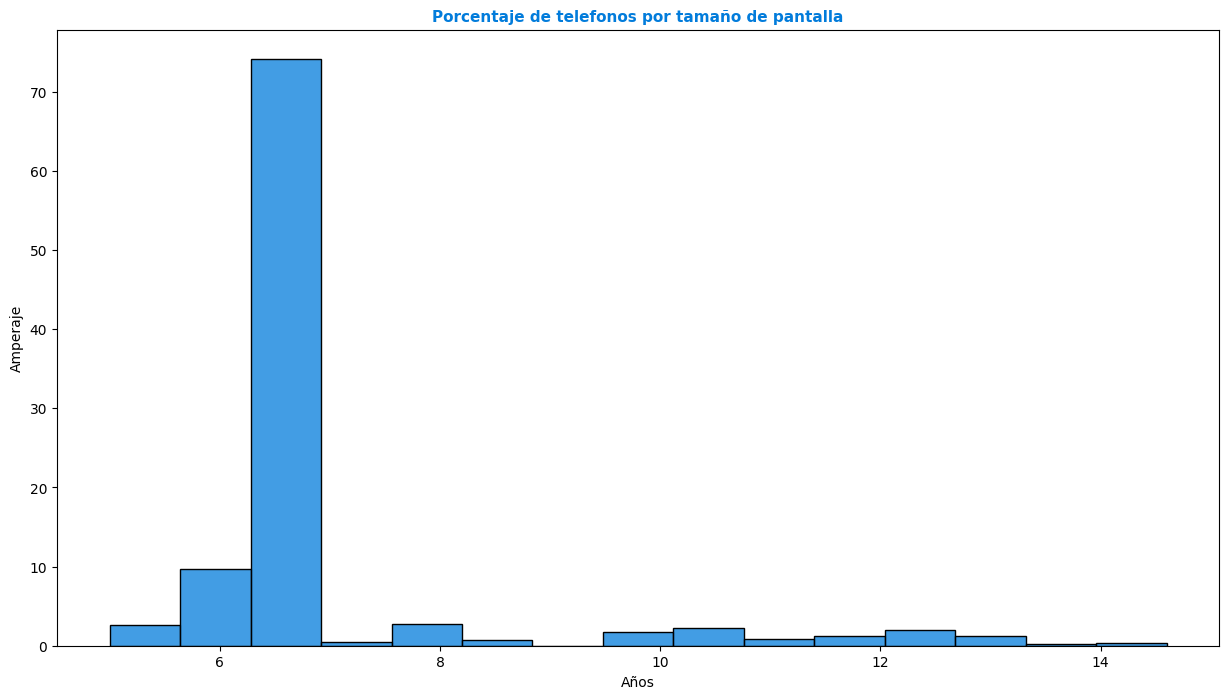

In [27]:
plt.figure(figsize = (15,8))
sns.histplot(df["Screen Size"], stat = "percent", color = '#027cdb', bins = 15)
plt.ylabel("Amperaje")
plt.xlabel("Años")
plt.title("Porcentaje de telefonos por tamaño de pantalla", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

Un **<span style="color:#57db02">80% de los dispositivos tienen pantalla menor a 7 pulgadas</span>**

In [28]:
df.loc[df['Company Name'] == 'Honor'].sort_values(by = 'Screen Size', ascending = False).head(1) 

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
890,Honor,Pad GT Pro,610,12,12MP,16MP,Qualcomm Snapdragon 8 Gen 3,10500,13.50,199999.00,84999,4999,999,3799,2024


El dispositivo atipico de Honor es una tablet con una pantalla que roza la de una laptop.

## 4. RAM

Aquí ya entramos en terreno peligroso aunque un poco engañoso. El mejor ejemplo de lo engañoso que es la RAM son los iPhone. El iPhone más potente tiene 8GB de RAM, mientras que el Android más potente tiene 16GB. Y en los distintos benchmarks la diferencia de rápidez es nula (en algunos casos es más rápido el iPhone). El uso de la RAM va de la mano con una buena optimización del sistema y la capa de personalización. Sin embargo, no deja de ser importante por más optimizado que este lo mencionado anteriormente.

In [29]:
# Extraemos los GB a lo largo del tiempo.
ram = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['RAM'].mean().rename(columns = {'RAM':'RAM_promedio'})
ram.head(2)

,Launched Year,Company Name,RAM_promedio
0,2014,Vivo,1.50
1,2016,Samsung,3.00


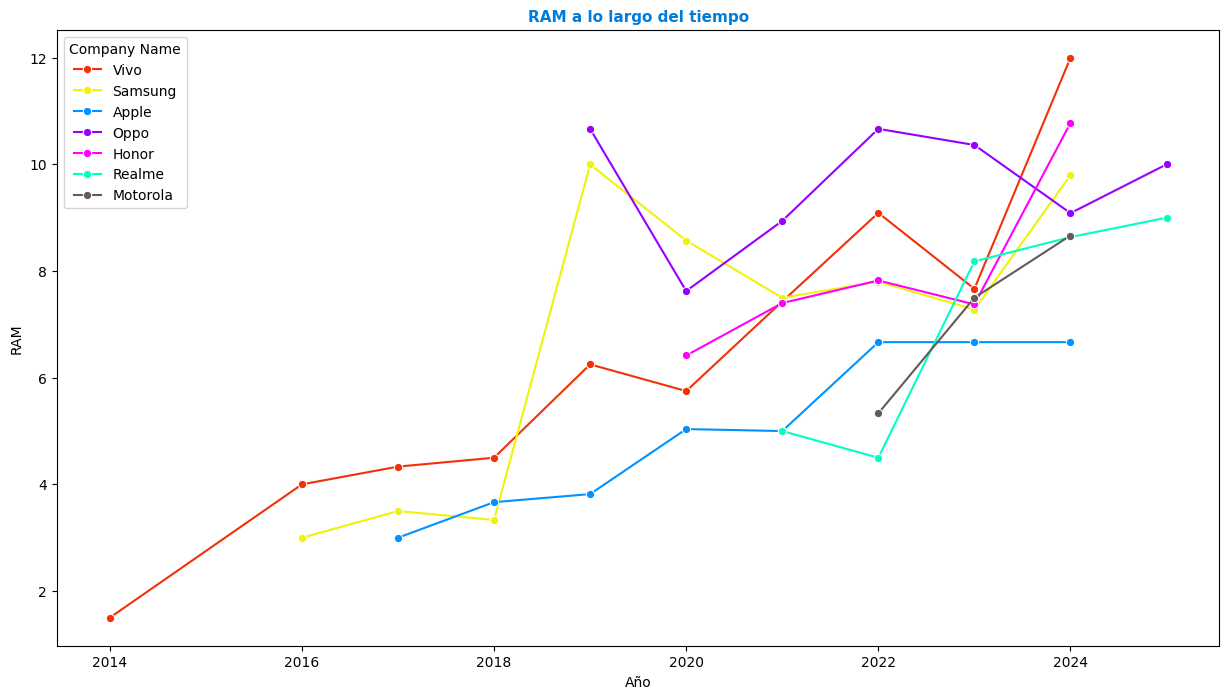

In [30]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
sns.lineplot(data = ram, x = 'Launched Year', y = 'RAM_promedio', hue = 'Company Name', palette = palette, marker = "o")
plt.title("RAM a lo largo del tiempo", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("RAM")
plt.show()

**<span style="color:#57db02">La mayoría de los dispositivos aumentan la RAM a lo largo del tiempo (lo esperable)</span>**

Su distribución se ve a continuación:

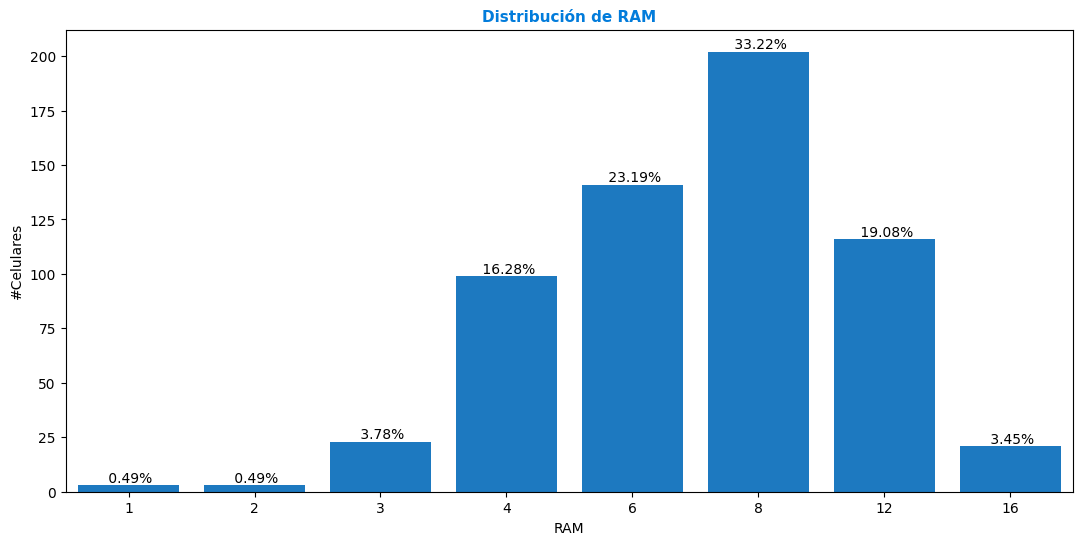

In [31]:
total = df['RAM'].shape[0]
plt.figure(figsize = (13,6))
ax = sns.countplot(df, x = 'RAM', color = '#027cdb')
for cont in ax.containers:
    ax.bar_label(cont, fmt = lambda x: f'{(x / total) * 100 : 0.2f}%')
plt.title("Distribución de RAM", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.ylabel("#Celulares")
plt.xlabel("RAM")
plt.show()

El **<span style="color:#57db02">56% de los dispositivos tienen 6 y 8 GB de RAM</span>**.

## 5. PROCESADOR

Estamos en terreno nerd y geek. Si alguien te habla de procesador sabe más que muchos promotores de venta de Telcel y At&t. El procesador es el cerebro de casi cualquier electrónico que alberga uno. Por tanto, es sumamente importante y ahora con el auge del IA todavía más.

Aqui, voy a hacer un poco de trampa, dado que me gusta mucho la tecnología y conozco del tema, entonces, sé que hay pocos fabricantes de procesadores. 

In [32]:
df.loc[df.Processor.str.contains('Snapdragon|Qualcomm', na = False, regex = True, case = False),'Procesador'] = 'Qualcomm'
df.loc[df.Processor.str.contains('MediaTek', na = False, regex = True, case = False),'Procesador'] = 'MediaTek'
df.loc[df.Processor.str.contains('Exynos', na = False, regex = True, case = False),'Procesador'] = 'Samsung'
df.loc[df.Processor.str.contains('Kirin', na = False, regex = True, case = False),'Procesador'] = 'Huawei'
df.loc[df.Processor.str.contains('Dimensity', na = False, regex = True, case = False),'Procesador'] = 'MediaTek'
df.loc[df.Processor.str.contains('Unisoc', na = False, regex = True, case = False),'Procesador'] = 'Unisoc'
df.loc[df.Processor.str.contains('A\d+', na = False, regex = True, case = False),'Procesador'] = 'Apple'

In [33]:
df.Procesador.value_counts(dropna = False)

Procesador
Qualcomm    234
MediaTek    210
Apple        97
Samsung      47
Unisoc       11
Huawei        8
NaN           1
Name: count, dtype: int64

In [34]:
df.loc[df.Procesador.isna(), 'Procesador'] = 'Samsung'

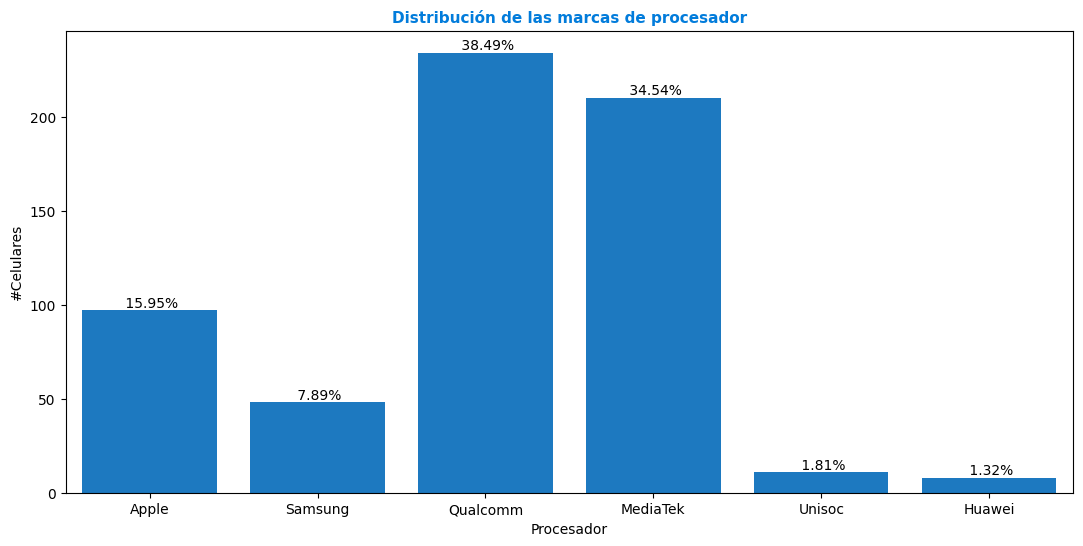

In [35]:
otal = df['Procesador'].shape[0]
plt.figure(figsize = (13,6))
ax = sns.countplot(df, x = 'Procesador', color = '#027cdb')
for cont in ax.containers:
    ax.bar_label(cont, fmt = lambda x: f'{(x / total) * 100 : 0.2f}%')
plt.title("Distribución de las marcas de procesador", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.ylabel("#Celulares")
plt.xlabel("Procesador")
plt.show()

Vemos que Qualcomm y Mediatek dominan el mercado con un **<span style="color:#57db02">73% ya que abarcan desde gama baja hasta gama premium</span>**.

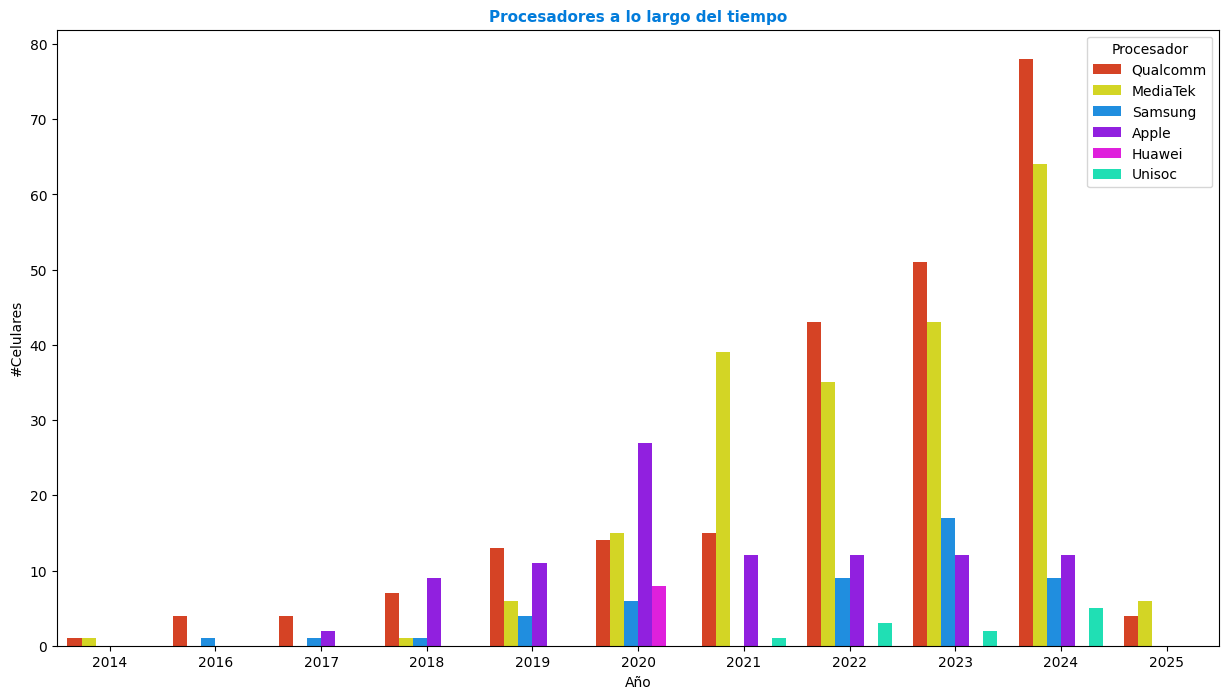

In [36]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
sns.countplot(data = df,  x = 'Launched Year',hue = "Procesador", palette = palette)
plt.ylabel("#Celulares")
plt.xlabel("Año")
plt.title("Procesadores a lo largo del tiempo", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

Es importante remarcar como **<span style="color:#57db02">en los últimos 3 años, Qualcomm y Mediatek han dominado el mercado,</span>** esto gracias a los múltiples dispositivos que los usan.

## 6. PRECIO

Existen distintos precios, sin embargo, por tema de tiempo y uso cotidiano vamos a usar el USD como variable precio.

Esta, es sin duda alguna el factor diferencial entre comprar un dispositivo o no. Exiten diversas razones, muchas de ellas sociales, del por qué el precio de un producto es sumamente importante. En casi todos los distintos servicios y productos al público el precio competitivo es vital para la supervivencia del mismo. Muy pocos pueden tener y justificar precios excesivamente altos. En el caso de los dispositivos móviles, no es la excepción.

In [37]:
# Vamos a revisar el precio promedio por año y marca
pric = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Launched Price (USA)'].mean().rename(columns = {'Launched Price (USA)':'Precio_Promedio'})
pric.head(2)

,Launched Year,Company Name,Precio_Promedio
0,2014,Vivo,169.00
1,2016,Samsung,219.00


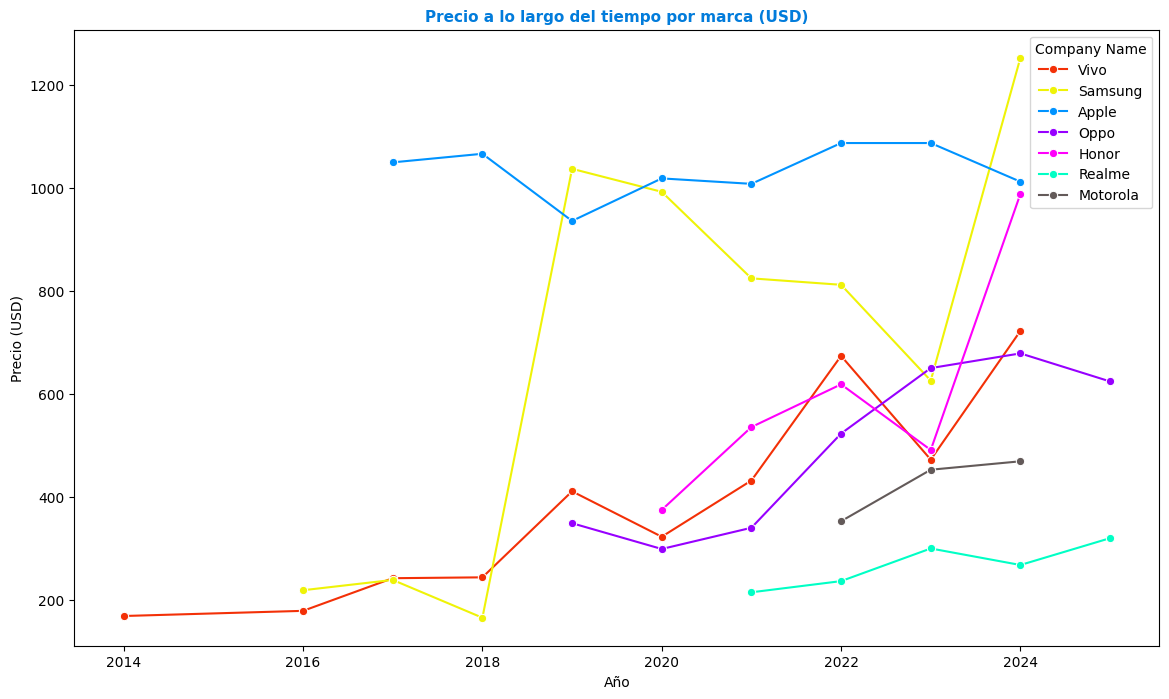

In [38]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (14,8))
sns.lineplot(data = pric, x = 'Launched Year', y = 'Precio_Promedio', hue = 'Company Name', palette = palette, marker = "o")
plt.title("Precio a lo largo del tiempo por marca (USD)", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("Precio (USD)")
plt.show()

Es claro que **<span style="color:#57db02">todas las marcas tienen una tendencia a la alza en sus precios</span>**, esto gracias al aumento del costo de fabricación de los dispositivos móviles.

In [39]:
pric = df.groupby(by = ['Launched Year', 'Company Name'], as_index = False)['Launched Price (USA)'].max().rename(columns = {'Launched Price (USA)':'Precio_Promedio'})
pric = pric.sort_values(by = ['Company Name', 'Launched Year'])
pric['Diferencia'] = pric.groupby(['Company Name'])['Precio_Promedio'].diff().fillna(0)
pric['%Cambio'] = pric.groupby(by = ['Company Name'], as_index = False)['Precio_Promedio'].pct_change()
pric['%Cambio'] = pric['%Cambio'].map('{:,.4f}'.format).astype(float) * 100

De hecho, la mayoría ha aumentado considerablemente el precio

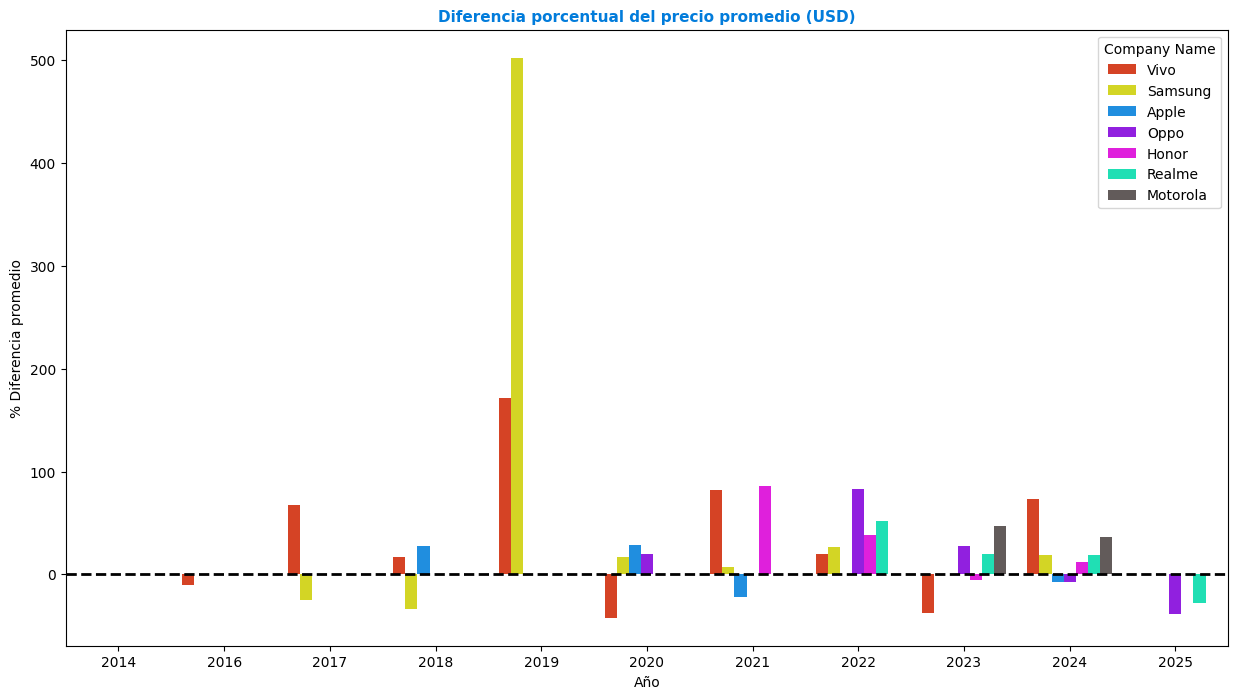

In [40]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
ax = sns.barplot(data = pric,  x = 'Launched Year', y = '%Cambio', hue = "Company Name", palette = palette)
ax.axhline(y = 0, linewidth = 2, color = 'black', ls = '--')
plt.ylabel("% Diferencia promedio")
plt.xlabel("Año")
plt.title("Diferencia porcentual del precio promedio (USD)", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

In [41]:
df.loc[(df['Launched Year'].isin([2018,2019]))  & (df['Company Name'] == 'Samsung')]

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Procesador
151,Samsung,Galaxy Note 10+ 256GB,196,12,10MP,12MP + 16MP,Exynos 9825,4300,6.80,160000.00,74999,6299,1099,3899,2019,Samsung
152,Samsung,Galaxy Note 10+ 512GB,196,12,10MP,12MP + 16MP,Exynos 9825,4300,6.80,180000.00,84999,6999,1199,4199,2019,Samsung
153,Samsung,Galaxy Note 10 256GB,168,8,10MP,12MP + 16MP,Exynos 9825,3500,6.30,140000.00,64999,5699,949,3699,2019,Samsung
154,Samsung,Galaxy Note 10 128GB,168,8,10MP,12MP + 16MP,Exynos 9825,3500,6.30,120000.00,59999,5199,899,3399,2019,Samsung
157,Samsung,Galaxy J8 64GB,191,4,16MP,16MP + 5MP,Snapdragon 450,3500,6.00,45000.00,18990,1699,199,799,2018,Qualcomm
159,Samsung,Galaxy J6+ 64GB,178,4,8MP,13MP + 5MP,Snapdragon 425,3300,6.00,40000.00,15999,1499,169,699,2018,Qualcomm
160,Samsung,Galaxy J4 16GB,175,2,5MP,13MP,Exynos 7570,3000,5.50,25000.00,9990,999,129,499,2018,Samsung


**Quitamos a Samsung, dado que no tenemos todos los telefonos de 2018**

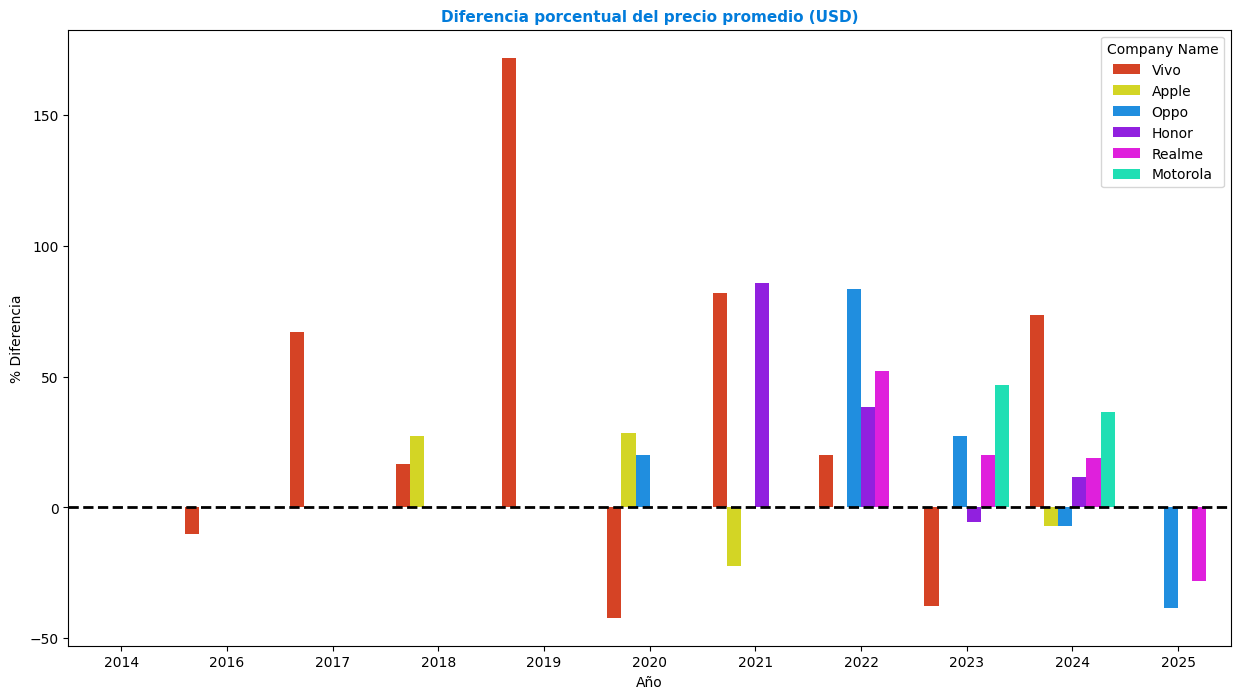

In [42]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
ax = sns.barplot(data = pric.loc[pric['Company Name'] != 'Samsung'],  x = 'Launched Year', y = '%Cambio', hue = "Company Name", palette = palette)
ax.axhline(y = 0, linewidth = 2, color = 'black', ls = '--')
plt.ylabel("% Diferencia")
plt.xlabel("Año")
plt.title("Diferencia porcentual del precio promedio (USD)", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

Si bien hacen falta algunos dispositivos de varias marcas, este ejercicio nos muestra como, en su gran mayoría, **<span style="color:#57db02">las marcas han aumentado el precio</span>**.

Si ha aumentado el precio, ¿también lo han hecho las especificaciones?

Veamos Cada uno de ellos con un gráfico de dispersión, perfecto para analizar relaciones entre variables

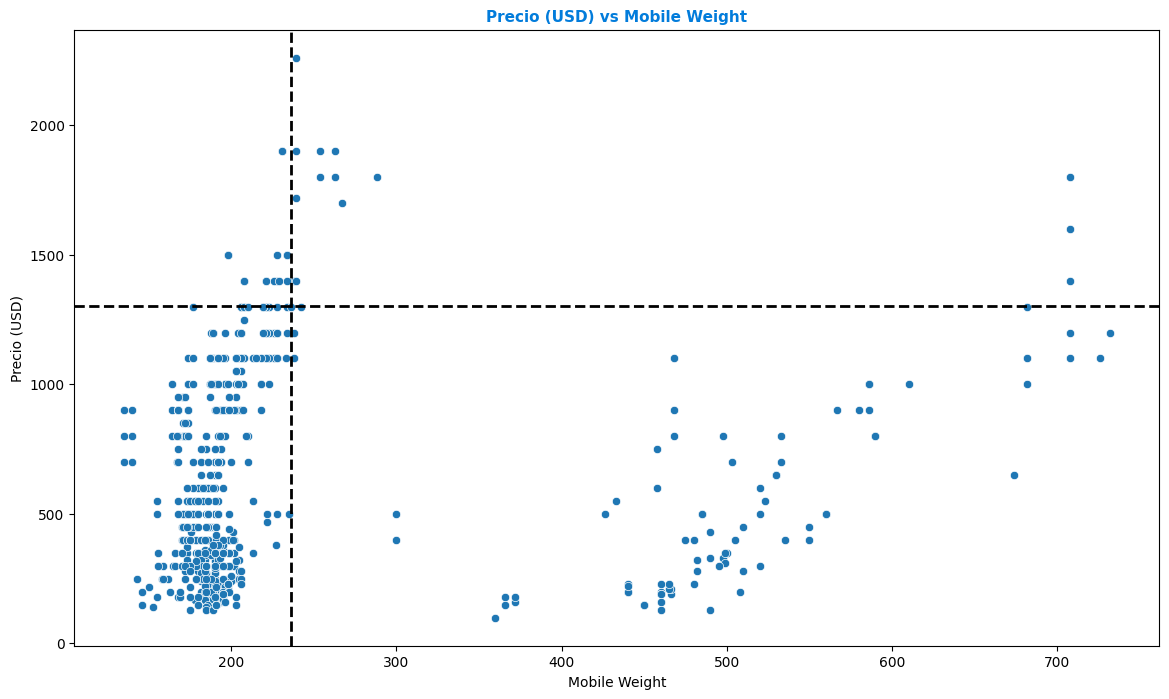

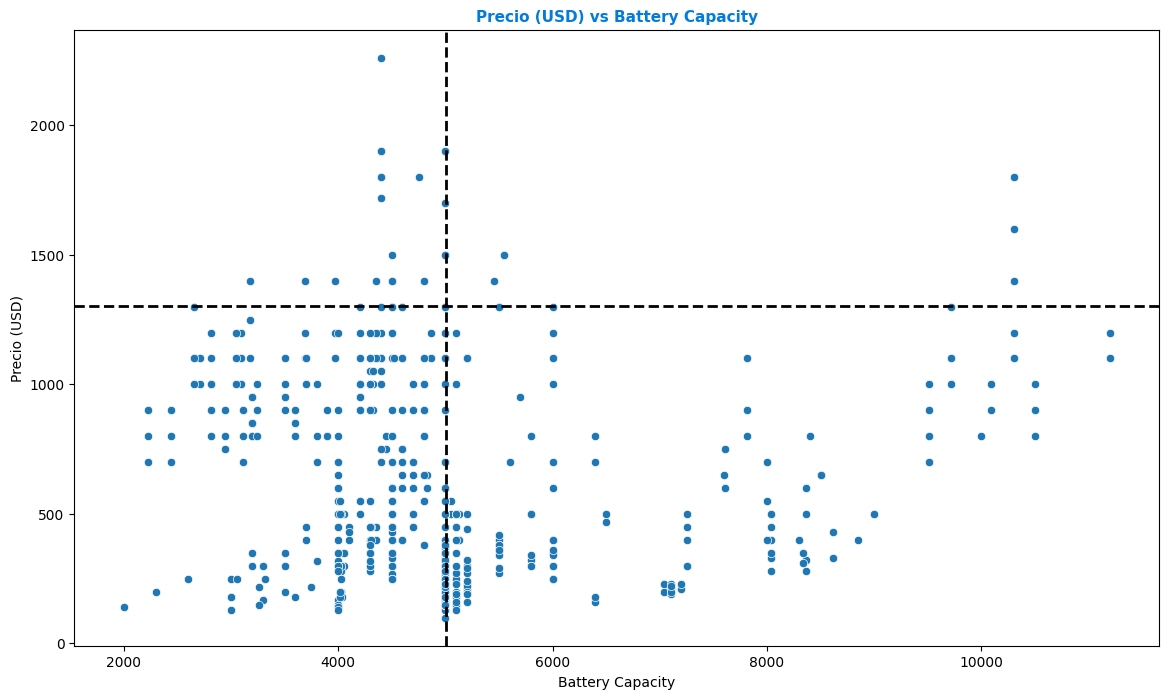

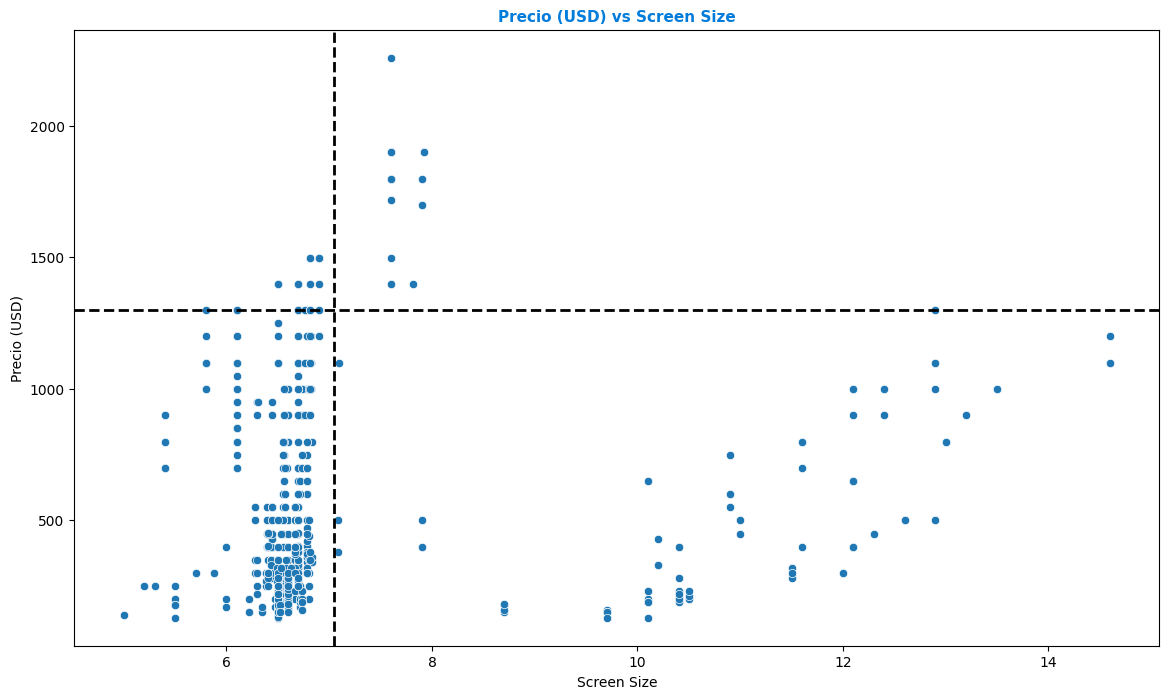

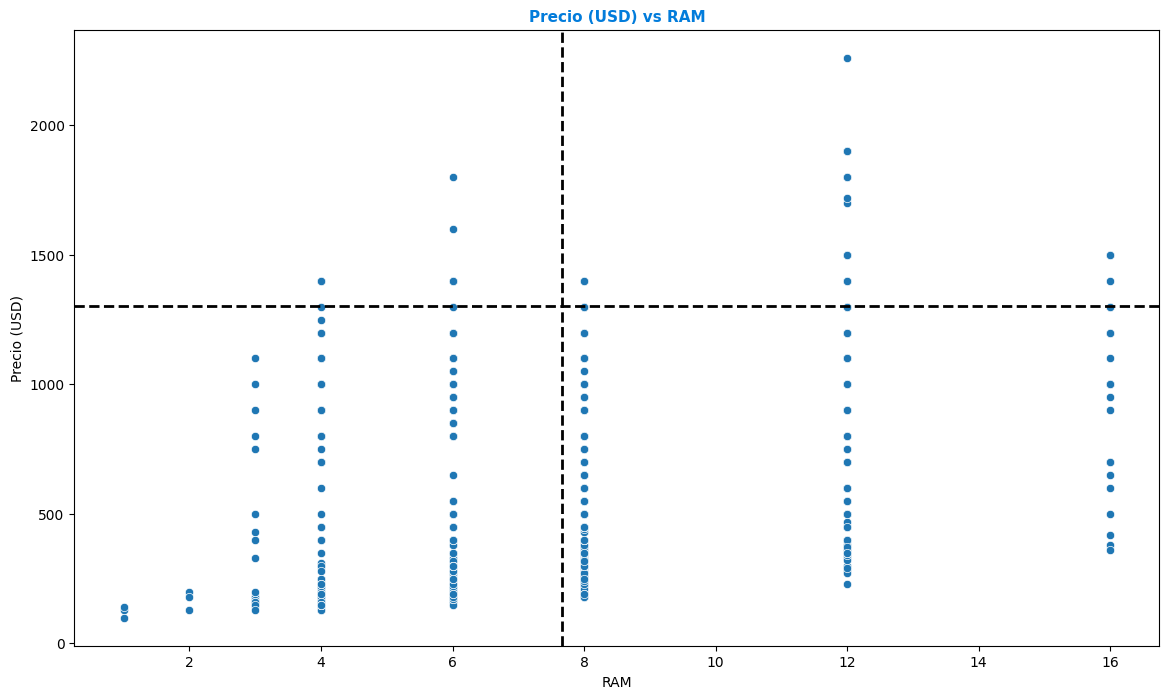

In [43]:
cols = ['Mobile Weight', 'Battery Capacity', 'Screen Size', 'RAM']
for ele in cols:
    plt.figure(figsize = (14,8))
    ax = sns.scatterplot(data = df, x = ele, y = 'Launched Price (USA)', palette = palette)
    ax.axhline(y = 1300, linewidth = 2, color = 'black', ls = '--')
    ax.axvline(x = df[ele].mean(), linewidth = 2, color = 'black', ls = '--') # Linea en el promedio
    plt.title(f"Precio (USD) vs {ele}", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
    plt.xlabel(f"{ele}")
    plt.ylabel("Precio (USD)")
    plt.show()

Es posible concluir que:
- **<span style="color:#57db02">El precio influye de manera inversa al peso, entre más caro, menor peso</span>**
- **<span style="color:#57db02">El precio no parece tener relación con la capacidad de bateria. La mayoría se encuentra debajo de 6000 mah</span>**
- **<span style="color:#57db02">De la misma manera que con la bateria, el precio no parece influir en el tamaño de la pantalla. De hecho, la gran mayoría de los dispositivos tienden a ser pequeños</span>**
- **<span style="color:#57db02">A medida que el precioa aumenta, tiende a aumentar el tamaño de la RAM. Aunque esta ha aumentado con el paso del tiempo</span>**

Vamos a revisar, cuál de todas las especificaciones analizadas han cambiado más a lo largo del tiempo. Para esto vamos a sacar la dif. porcentual por año y marca

In [44]:
df['Bateria%Cambio'] = df.groupby(by = ['Launched Year', 'Company Name'], as_index = True).agg({'Battery Capacity':'pct_change'}) * 100
df['Peso%Cambio'] = df.groupby(by = ['Launched Year','Company Name'], as_index = True).agg({'Mobile Weight':'pct_change'}) * 100
df['RAM%Cambio'] = df.groupby(by = ['Launched Year','Company Name'], as_index = True).agg({'RAM':'pct_change'}) * 100
df['Pantalla%Cambio'] = df.groupby(by = ['Launched Year','Company Name'], as_index = True).agg({'Screen Size':'pct_change'}) * 100
df['Precio%Cambio'] = df.groupby(by = ['Launched Year','Company Name'], as_index = True).agg({'Launched Price (USA)':'pct_change'}) * 100

In [45]:
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Procesador,Bateria%Cambio,Peso%Cambio,RAM%Cambio,Pantalla%Cambio,Precio%Cambio
0,Apple,iPhone 16 128GB,174,6,12MP,48MP,A17 Bionic,3600,6.10,224999.00,79999,5799,799,2799,2024,Apple,NaN,NaN,NaN,NaN,NaN
1,Apple,iPhone 16 256GB,174,6,12MP,48MP,A17 Bionic,3600,6.10,234999.00,84999,6099,849,2999,2024,Apple,0.00,0.00,0.00,0.00,6.26
2,Apple,iPhone 16 512GB,174,6,12MP,48MP,A17 Bionic,3600,6.10,244999.00,89999,6499,899,3199,2024,Apple,0.00,0.00,0.00,0.00,5.89
3,Apple,iPhone 16 Plus 128GB,203,6,12MP,48MP,A17 Bionic,4200,6.70,249999.00,89999,6199,899,3199,2024,Apple,16.67,16.67,0.00,9.84,0.00
4,Apple,iPhone 16 Plus 256GB,203,6,12MP,48MP,A17 Bionic,4200,6.70,259999.00,94999,6499,949,3399,2024,Apple,0.00,0.00,0.00,0.00,5.56


In [46]:
cap2 = df.groupby(by = ['Launched Year'], as_index = False).agg({'Bateria%Cambio':'mean','Peso%Cambio':'mean', 'RAM%Cambio':'mean', 'Pantalla%Cambio':'mean', 'Precio%Cambio':'mean'}). \
    rename(columns = {'Bateria%Cambio':'Capacidad de bateria','Peso%Cambio':'Peso','Precio%Cambio':'Precio', 'Pantalla%Cambio':'Pantalla','RAM%Cambio':'RAM'}) # Por cada dif obtenemos el promedio por año
cap2['RAM'] = round(cap2.RAM, 0)
cap2.head(2)

,Launched Year,Capacidad de bateria,Peso,RAM,Pantalla,Precio
0,2014,-13.04,4.79,-50.00,-9.09,-30.15
1,2016,19.10,63.93,-36.00,26.97,-36.35


In [47]:
data = pd.melt(cap2, id_vars = ['Launched Year'], value_vars = ['Capacidad de bateria','Peso','RAM','Precio'], var_name = 'Varible', value_name = 'Desviacion')

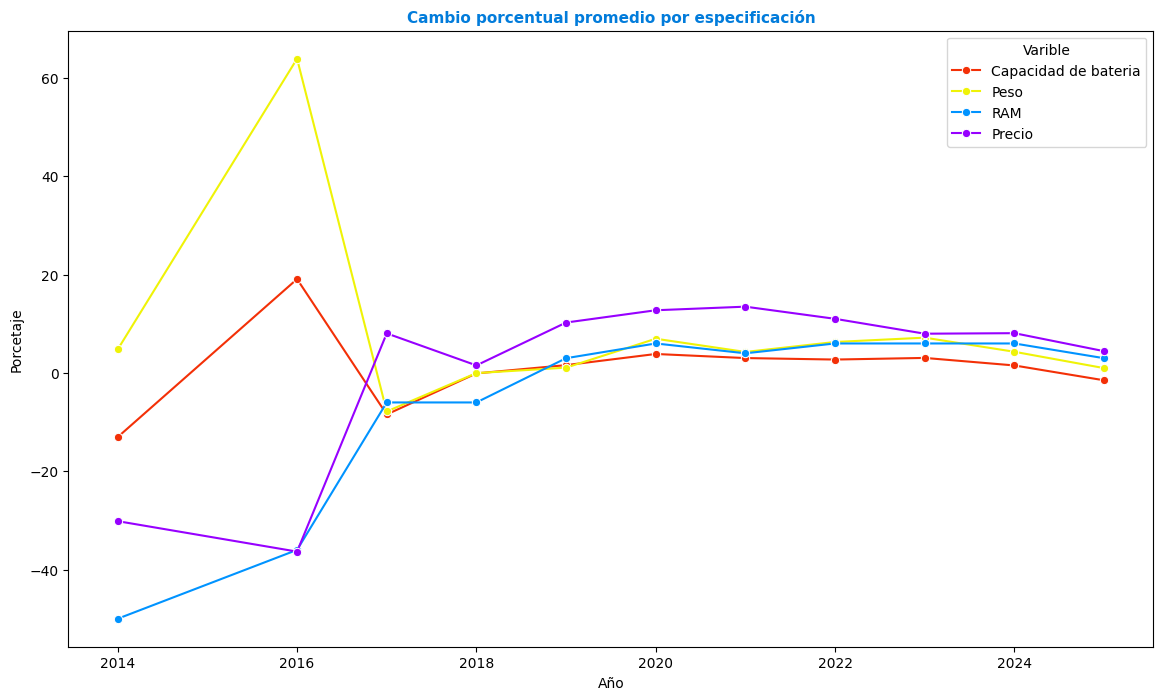

In [48]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff"]
plt.figure(figsize = (14,8))
sns.lineplot(data = data, x = 'Launched Year', y = 'Desviacion', hue = 'Varible', palette = palette, marker = "o")
plt.title("Cambio porcentual promedio por especificación", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.xlabel("Año")
plt.ylabel("Porcetaje")
plt.show()

**<span style="color:#57db02">Se pueden ver bruscas fluctuaciones entre 2016 y 2017</span>**. No obstante, vemos que la **<span style="color:#57db02">RAM es la variable que más ha fluctuado a lo largo del tiempo</span>**. Mientras que el precio presenta una tendencia a la alza considerable.

Finalmente, ¿cómo se relacionan las especificaciones? ¿Entre más peso más batería?

Usemos la correlación de pearson

In [49]:
cor = df.select_dtypes(include = 'number')
cor = cor.drop(columns = ['Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (Dubai)'])

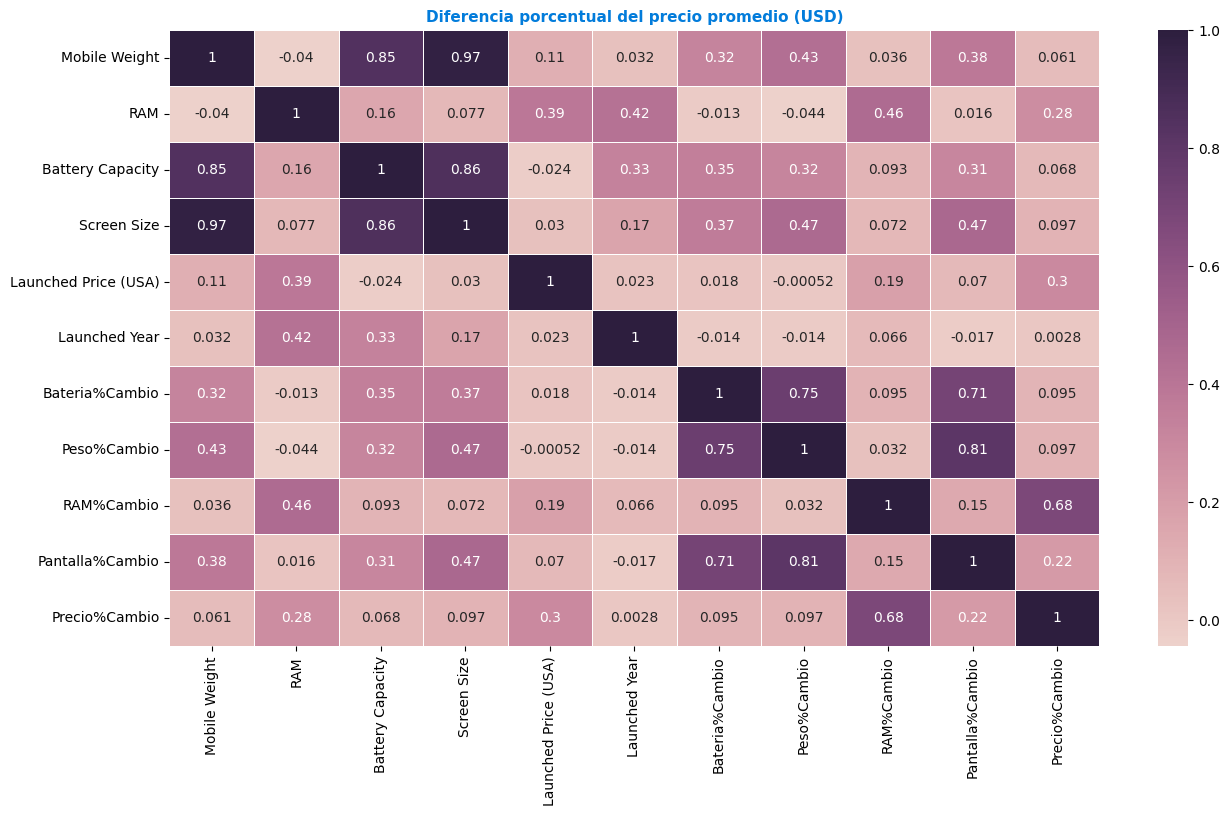

In [50]:
palette = ["#f33007", "#eff307", "#0093ff", "#9700ff", "#ff00fb", "#00ffc5", "#635a59"]
plt.figure(figsize = (15,8))
sns.heatmap(cor.corr(), annot = True, linewidth = .5, cmap = sns.cubehelix_palette(as_cmap = True))
plt.ylabel("")
plt.xlabel("")
plt.title("Diferencia porcentual del precio promedio (USD)", fontdict = {'fontsize': 11, 'fontweight': 'bold', 'color': '#027cdb'})
plt.show()

Se observa lo esperable:

1. **<span style="color:#57db02">Entre mayor sea la capacidad de bateria mayor será el peso del dispositivo</span>**
2. **<span style="color:#57db02">Entre más grande la pantalla mayor será el peso del dispositivo</span>**
3. **<span style="color:#57db02">Entre más grande sea la pantalla mayor será la capacidad de bateria.</span>**

Aunque la número 2 es casi un hecho. Si se desea implementar algún modelo de predicción de precio se debe remover una de ellas dos debido a la correlación tan alta que existe, puede reducir la varianza y ocasionar un modelo erroneo.

# BONUS

In [51]:
#¿Cuáles son los 3 dispositivos más caros historicamente?
df.sort_values(by = 'Launched Price (USA)', ascending = False).head(3)

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Procesador,Bateria%Cambio,Peso%Cambio,RAM%Cambio,Pantalla%Cambio,Precio%Cambio
929,Samsung,Galaxy Z Fold6 1TB,239,12,10MP 4MP (UDC),50MP,Snapdragon 8 Gen 3,4400,7.60,NaN,200999,17999,2259,8699,2024,Qualcomm,0.00,0.00,0.00,0.00,31.41
869,Honor,Magic V3,231,12,16MP,50MP,Qualcomm Snapdragon 8 Gen 2,5000,7.92,389999.00,159999,10999,1899,6999,2024,Qualcomm,-9.91,-1.28,-25.00,16.30,26.68
116,Samsung,Galaxy Z Fold 5 512GB,254,12,10MP,50MP + 12MP,Snapdragon 8 Gen 2,4400,7.60,550000.00,174900,12999,1899,7499,2023,Qualcomm,0.00,0.00,0.00,0.00,5.56


In [52]:
# ¿Qué marcas tienen más dispositivos?
df.groupby(by = 'Company Name', as_index = False)['Model Name'].count().rename(columns = {'Model Name':'#Celulares'}).sort_values(by = '#Celulares', ascending = False).head()

,Company Name,#Celulares
3,Oppo,115
0,Apple,97
1,Honor,91
5,Samsung,88
6,Vivo,86


In [53]:
#¿Cuáles son los 3 marcas más caras historicamente?
maxi = df.groupby(by = 'Company Name', as_index = False)['Launched Price (USA)'].max().rename(columns = {'Launched Price (USA)':'PrecioMax'})
prom = df.groupby(by = 'Company Name', as_index = False)['Launched Price (USA)'].mean().rename(columns = {'Launched Price (USA)':'PrecioProm'})
medio = df.groupby(by = 'Company Name', as_index = False)['Launched Price (USA)'].median().rename(columns = {'Launched Price (USA)':'PrecioMedio'})
precios = maxi.merge(prom, on = 'Company Name').merge(medio, on = 'Company Name')
precios['Pond'] = precios.PrecioMax * 0.9 + precios.PrecioProm + precios.PrecioMedio * 1.1 # Suma ponderada donde le doy mas peso al precio mediano y menos al precio max
precios = precios.sort_values(by = ['Pond'], ascending = False)
precios.head(4)


,Company Name,PrecioMax,PrecioProm,PrecioMedio,Pond
0,Apple,1799,1028.48,999.00,3746.48
5,Samsung,2259,748.43,699.00,3550.43
1,Honor,1899,607.57,449.00,2810.57
3,Oppo,1399,535.35,499.00,2343.35


In [54]:
#¿Cuáles son los 3 marcas más baratas historicamente?
precios.tail(3)

,Company Name,PrecioMax,PrecioProm,PrecioMedio,Pond
2,Motorola,1499,433.26,349.00,2166.26
6,Vivo,1299,469.47,399.00,2077.47
4,Realme,500,273.33,250.00,998.33


In [55]:
#¿Cuál es el dispositivo con la mejor relacion bateria - pantalla historicamente?
df['Relacion'] = df['Battery Capacity'] / df['Screen Size']
df.loc[df.Relacion == df.Relacion.max()]

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Procesador,Bateria%Cambio,Peso%Cambio,RAM%Cambio,Pantalla%Cambio,Precio%Cambio,Relacion
453,Realme,GT 7 Pro 128GB,222,12,16MP,50MP + 50MP + 8MP,Qualcomm Snapdragon 8 Elite,6500,6.78,139999.00,59999,3400,470,1725,2024,Qualcomm,NaN,NaN,NaN,NaN,NaN,958.70
454,Realme,GT 7 Pro 256GB,222,16,16MP,50MP + 50MP + 8MP,Qualcomm Snapdragon 8 Elite,6500,6.78,149999.00,65999,3600,500,1840,2024,Qualcomm,0.00,0.00,33.33,0.00,6.38,958.70


In [56]:
# ¿Cuándo comenzó la moda de la doble cámara trasera?
df.loc[df['Back Camera'].str.contains("\+", na = False, regex = True, case = False), 'Doble_Camara'] = 1 # En los datos se indica con un + si posee dos o màs càmaras
df.loc[(df.Doble_Camara == 1)]['Launched Year'].min()

2016

Muchas por su tiempo.

By Erwin